Swarm intelligence 

lib needed : 


aco-tsp-project
│
├── aco.py
├── visualization.py
├── main.py
├── requirements.txt
└── README.md

Iteration 1, Best Length = 353.69
Iteration 2, Best Length = 329.47
Iteration 3, Best Length = 328.55
Iteration 4, Best Length = 328.55
Iteration 5, Best Length = 328.55
Iteration 6, Best Length = 328.55
Iteration 7, Best Length = 328.55
Iteration 8, Best Length = 321.57
Iteration 9, Best Length = 321.57
Iteration 10, Best Length = 321.57
Iteration 11, Best Length = 321.57
Iteration 12, Best Length = 321.57
Iteration 13, Best Length = 321.57
Iteration 14, Best Length = 321.57
Iteration 15, Best Length = 321.57
Iteration 16, Best Length = 321.57
Iteration 17, Best Length = 321.57
Iteration 18, Best Length = 321.57
Iteration 19, Best Length = 321.57
Iteration 20, Best Length = 321.57
Iteration 21, Best Length = 321.57
Iteration 22, Best Length = 321.57
Iteration 23, Best Length = 321.57
Iteration 24, Best Length = 321.57
Iteration 25, Best Length = 321.57
Iteration 26, Best Length = 321.57
Iteration 27, Best Length = 321.57
Iteration 28, Best Length = 321.57
Iteration 29, Best Length = 3

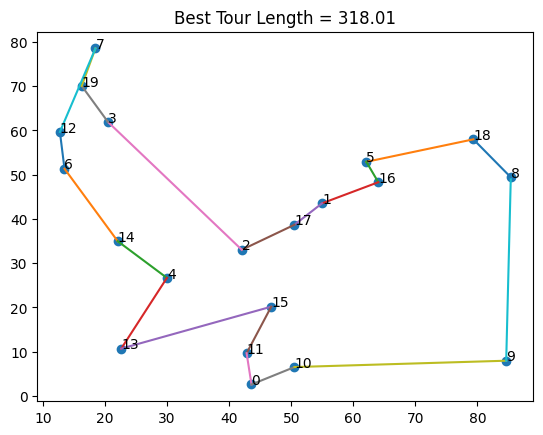

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ===============================
# PARAMETERS
# ===============================

NUM_CITIES = 20        # number of cities
NUM_ANTS = 20          # number of ants
ITERATIONS = 100       # number of iterations

ALPHA = 1              # pheromone importance
BETA = 5               # distance importance
RHO = 0.5              # evaporation rate
Q = 100                # pheromone deposit factor

# ===============================
# GENERATE RANDOM CITIES
# ===============================

np.random.seed(2) # tasbet no3 wahed mn el randomness fl arkam 3lshan lma tege tsh8al el code kza mara yastl3 nafs el result wanta b tdevelop
cities = np.random.rand(NUM_CITIES, 2) * 100 # np.random.rand(rows, columns) make matrix
# 20 x 2 matrix --- every city have x and y cordeintes 
# why * 100 ?  0.41 0.72 results to  41 72 ( more clear )


# ===============================
# DISTANCE MATRIX
# ===============================

distance = np.zeros((NUM_CITIES, NUM_CITIES))

for i in range(NUM_CITIES):
    for j in range(NUM_CITIES):
        if i != j:
            distance[i][j] = np.linalg.norm(cities[i] - cities[j]) # Euclidean Distance. root((x)**2 + (y)**2)
        else:
            distance[i][j] = np.inf # cannot be choosen or predicted so put inf (infinte)


# ===============================
# PHEROMONE INITIALIZATION
# ===============================

pheromone = np.ones((NUM_CITIES, NUM_CITIES)) * 0.0001 # ones 20 x 20 matrix 
# * 0.0001 for making random pheromone and equal first to dont give piroty to any road 


# ===============================
# FUNCTION: CHOOSE NEXT CITY
# ===============================

def choose_next_city(current, visited):

    probabilities = np.zeros(NUM_CITIES)

    for j in range(NUM_CITIES):
        if j not in visited:
            tau = pheromone[current][j] ** ALPHA
            eta = (1 / distance[current][j]) ** BETA
            probabilities[j] = tau * eta

    total = np.sum(probabilities)

    if total == 0:
        return random.choice(list(set(range(NUM_CITIES)) - set(visited)))

    probabilities = probabilities / total

    return np.random.choice(range(NUM_CITIES), p=probabilities)


# ===============================
# FUNCTION: TOUR LENGTH
# ===============================

def tour_length(tour):

    length = 0

    for i in range(len(tour) - 1):
        length += distance[tour[i]][tour[i+1]]

    length += distance[tour[-1]][tour[0]]

    return length


# ===============================
# MAIN ACO ALGORITHM
# ===============================

best_tour = None
best_length = float("inf")

for iteration in range(ITERATIONS):

    all_tours = []
    all_lengths = []

    for ant in range(NUM_ANTS):

        start = random.randint(0, NUM_CITIES-1)

        tour = [start]

        while len(tour) < NUM_CITIES:

            current = tour[-1]

            next_city = choose_next_city(current, tour)

            tour.append(next_city)

        length = tour_length(tour)

        all_tours.append(tour)
        all_lengths.append(length)

        if length < best_length:
            best_length = length
            best_tour = tour

    # ===============================
    # PHEROMONE EVAPORATION
    # ===============================

    pheromone = (1 - RHO) * pheromone

    # ===============================
    # PHEROMONE UPDATE
    # ===============================

    for k in range(NUM_ANTS):

        tour = all_tours[k]
        length = all_lengths[k]

        for i in range(NUM_CITIES - 1):

            a = tour[i]
            b = tour[i+1]

            pheromone[a][b] += Q / length
            pheromone[b][a] += Q / length

        pheromone[tour[-1]][tour[0]] += Q / length
        pheromone[tour[0]][tour[-1]] += Q / length

    print(f"Iteration {iteration+1}, Best Length = {best_length:.2f}")


# ===============================
# VISUALIZE RESULT
# ===============================

x = cities[:,0]
y = cities[:,1]

plt.scatter(x, y)

for i in range(NUM_CITIES):
    plt.text(x[i], y[i], str(i))

for i in range(NUM_CITIES-1):
    a = best_tour[i]
    b = best_tour[i+1]

    plt.plot([cities[a][0], cities[b][0]],
             [cities[a][1], cities[b][1]])

a = best_tour[-1]
b = best_tour[0]

plt.plot([cities[a][0], cities[b][0]],
         [cities[a][1], cities[b][1]])

plt.title(f"Best Tour Length = {best_length:.2f}")

plt.show()